Status: optimal
Custo Total: 3801.17 $/hora

Geração das Usinas (MVA):
 Usina 1: 95.4 MVA
 Usina 2: 89.3 MVA
 Usina 3: 35.4 MVA

Nível do Reservatório (hm³):
 Reservatório 1: 14.6 hm³
 Reservatório 2: 20.7 hm³

Fluxo nas Linhas de Transmissão (MVA):
 Linha 1: 5.4 MVA
 Linha 2: 70.0 MVA
 Linha 3: 64.6 MVA

Ângulo das Tensões (rad):
 Barra 1: 0.0000 rad
 Barra 2: -5.3587 rad
 Barra 3: -70.0000 rad


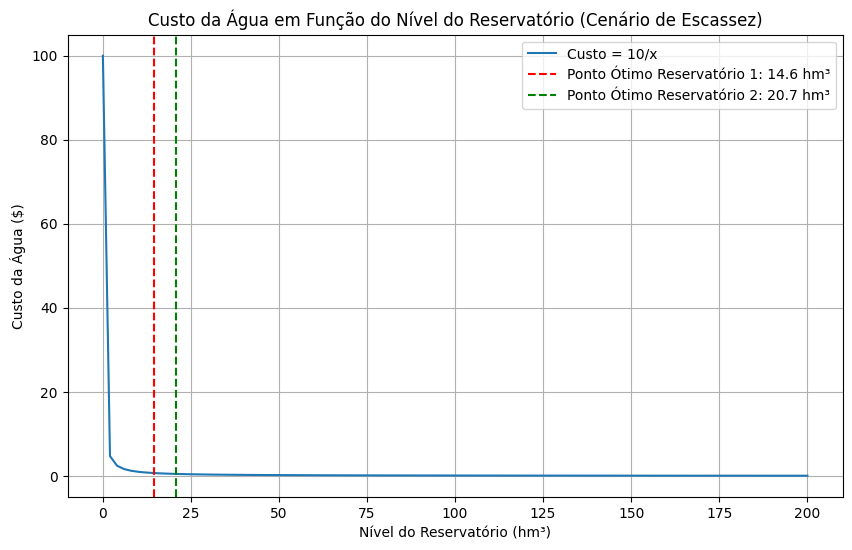

In [3]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# --- Dados do Sistema ---
n_usinas = 3
n_linhas = 3
n_cargas = 3
n_reservatorios = 2

# Custo incremental das usinas ($/MVAh)
c = np.array([10, 20, 30])

# Capacidade máxima das usinas (MVA)
P_max = np.array([100, 150, 200])

# Capacidade das linhas de transmissão (MVA)
F_max = np.array([50, 70, 80])

# Demanda das cargas (MVA)
D = np.array([20, 30, 170])

# Matriz de incidência das linhas (Topologia da rede)
A = np.array([
    [1, -1, 0],
    [1, 0, -1],
    [0, 1, -1]
])

# Nível inicial dos reservatórios (hm³)
x0 = np.array([100, 100])

# Afluência (hm³/h)
a = np.array([10, 10])

# Eficiência hidroelétrica
eta = np.array([1, 1])

# --- Cenário de Escassez: Custo não linear da água ---
# Constante para a penalidade de escassez (ajuste conforme a necessidade)
K_scarcity = 10

# --- Variáveis de Otimização ---
P = cp.Variable(n_usinas) # Geração (MVA)
F = cp.Variable(n_linhas) # Fluxo (MVA)
theta = cp.Variable(n_cargas) # Ângulo (rad)
x = cp.Variable(n_reservatorios) # Nível do reservatório (hm³)

# --- Função Objetivo ---
# Custo total: Custo das usinas + Custo não linear da água (inverso do nível do reservatório)
obj = cp.Minimize(c @ P + K_scarcity * cp.sum(cp.inv_pos(x))) # cp.inv_pos(x) = 1/x para x > 0

# --- Restrições ---
constraints = [
    cp.sum(P) == cp.sum(D), # Balanço Global de Potência
    P <= P_max, # Limite de Geração
    P >= 0, # Geração não-negativa
    F == A @ theta, # Lei de Kirchhoff para Fluxo DC
    F <= F_max, # Limite térmico da linha (Direto)
    F >= -F_max, # Limite térmico da linha (Reverso)
    theta[0] == 0, # Barra de Referência (Slack Bus)
    x == x0 + a - cp.multiply(eta, P[:2]), # Dinâmica dos reservatórios (alterado para cp.multiply)
    x >= 0.1 # Nível do reservatório deve ser estritamente positivo para cp.inv_pos (ou evitar valores muito pequenos)
] # Ajustado para x >= 0.1 para evitar problemas com 1/x muito próximos de zero

# Adicionando o Balanço de Carga por Barra (Lei de Kirchhoff das Correntes)
constraints += [P - D == A.T @ F]

# --- Solução do Problema ---
prob = cp.Problem(obj, constraints)
prob.solve()

# --- Exibição dos Resultados ---
if prob.status == 'optimal':
    print(f"Status: {prob.status}")
    print(f"Custo Total: {prob.value:.2f} $/hora\n")
    print("Geração das Usinas (MVA):")
    for i in range(n_usinas):
        print(f" Usina {i+1}: {P.value[i]:.1f} MVA")
    print("\nNível do Reservatório (hm³):")
    for i in range(n_reservatorios):
        print(f" Reservatório {i+1}: {x.value[i]:.1f} hm³")
    print("\nFluxo nas Linhas de Transmissão (MVA):")
    for i in range(n_linhas):
        print(f" Linha {i+1}: {F.value[i]:.1f} MVA")
    print("\nÂngulo das Tensões (rad):")
    for i in range(n_cargas):
        print(f" Barra {i+1}: {theta.value[i]:.4f} rad")
else:
    print(f"O problema não encontrou uma solução ótima. Status: {prob.status}")
    print("Verifique as restrições ou a convexidade da função objetivo.")

# --- Gráfico do custo da água (Não Linear) ---
# Criando valores para o eixo x, garantindo que não há zero para 1/x
x_vals_plot = np.linspace(0.1, 200, 100)
custo_vals_non_linear = K_scarcity / x_vals_plot

plt.figure(figsize=(10, 6))
plt.plot(x_vals_plot, custo_vals_non_linear, label=f'Custo = {K_scarcity}/x')
plt.xlabel('Nível do Reservatório (hm³)')
plt.ylabel('Custo da Água ($)')
plt.title('Custo da Água em Função do Nível do Reservatório (Cenário de Escassez)')
plt.grid(True)

# Plotando os pontos ótimos dos reservatórios, se existirem e forem positivos
if prob.status == 'optimal':
    if x.value[0] > 0:
        plt.axvline(x=x.value[0], color='r', linestyle='--', label=f'Ponto Ótimo Reservatório 1: {x.value[0]:.1f} hm³')
    if x.value[1] > 0:
        plt.axvline(x=x.value[1], color='g', linestyle='--', label=f'Ponto Ótimo Reservatório 2: {x.value[1]:.1f} hm³')

plt.legend()
plt.show()